# 🛒 E-Commerce Sales Analytics using MySQL & Python

## Project Overview

This project analyzes a real-world e-commerce dataset using **MySQL** and **Python** to uncover customer behavior, sales performance, product trends, payment patterns, and operational insights.

The project combines SQL-based business analysis with Python visualizations to generate actionable insights that support data-driven decision making.

---

### Tech Stack

- MySQL
- SQL
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

---

### Project Workflow

1. Import CSV data into MySQL
2. Perform SQL-based business analysis
3. Extract results using Python
4. Create visualizations
5. Generate business insights and recommendations

## 🎯 Business Objective

The objective of this project is to analyze a real-world Brazilian e-commerce dataset to uncover actionable business insights related to customer behavior, sales performance, product categories, payment methods, and seller performance.

Using SQL for data extraction and Python for visualization, this project answers key business questions that can help decision-makers optimize sales strategy, improve customer experience, and increase overall business profitability.

## 📊 Dataset Description

This project uses the Brazilian Olist E-Commerce Dataset, which contains over 100,000 customer orders across multiple interconnected tables.

### Dataset Highlights

- **Orders:** 100K+
- **Customers:** 99K+
- **Products:** 32K+
- **Sellers:** 3K+
- **Multiple relational tables linked using MySQL**

### Technologies Used

- MySQL
- SQL
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

# 🔗 Database Connection

In this section, Python is used to establish a connection with the MySQL database containing the e-commerce dataset. The connection enables execution of SQL queries directly from Python for analysis and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db = mysql.connector.connect(host = "localhost",
                             user = "root",
                             password = "@201517#aa",
                             database = "ecommerce")

cur = db.cursor()

# 👥 Customer Analysis

This section explores customer distribution, customer locations, and purchasing behavior across different regions.

List all unique cities where customers are located.

In [ ]:
# query = """select distinct customer_city from customers """
# cur.execute(query)
# data = cur.fetchall()
# data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

### Customer Distribution by State

In [17]:
query = """
SELECT
    customer_state,
    COUNT(customer_id) AS total_customers
FROM customers
GROUP BY customer_state
ORDER BY total_customers DESC;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=["State", "Customers"])

df

,State,Customers
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


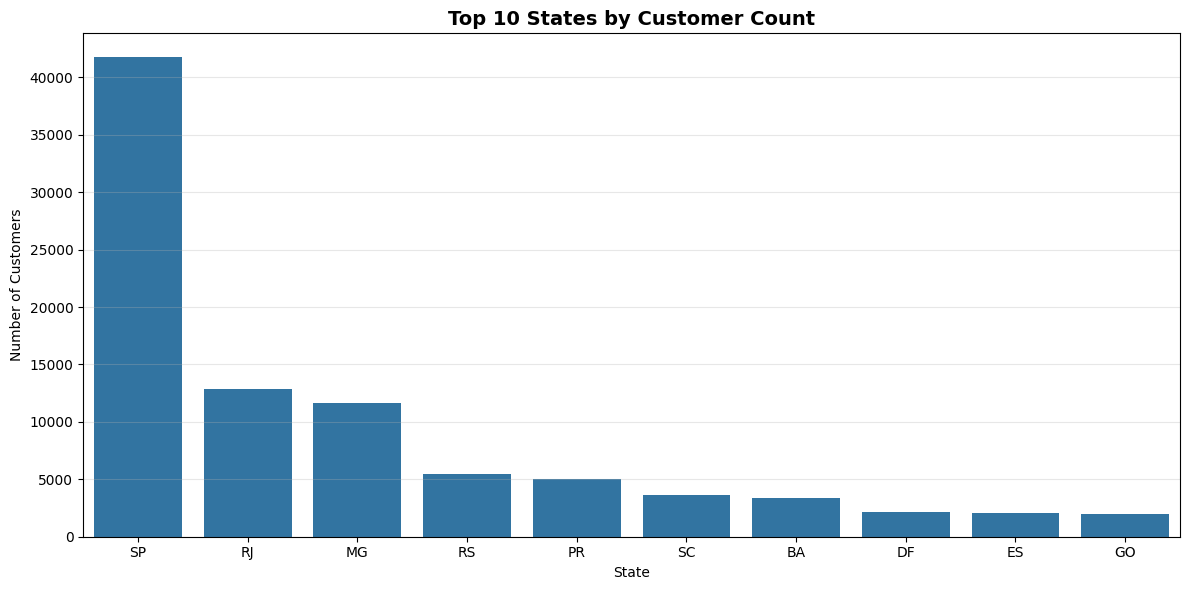

In [18]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df.head(10),
    x="State",
    y="Customers"
)

plt.title("Top 10 States by Customer Count", fontsize=14, weight="bold")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### 💡 Business Insights

- São Paulo has the highest customer concentration, indicating it is the company's largest market.
- Customer demand is primarily concentrated in the South and Southeast regions of Brazil.
- High-density states should receive priority for marketing campaigns and inventory planning.
- Low-customer states represent potential expansion opportunities through targeted promotions.

# 📈 Sales Performance Analysis

This section analyzes order volume and sales trends over different time periods to evaluate business growth.

Count the number of orders placed in 2017

In [19]:
query = """
SELECT
    MONTHNAME(order_purchase_timestamp) AS Month,
    COUNT(order_id) AS Total_Orders
FROM orders
WHERE YEAR(order_purchase_timestamp) = 2017
GROUP BY MONTH(order_purchase_timestamp), MONTHNAME(order_purchase_timestamp)
ORDER BY MONTH(order_purchase_timestamp);
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=["Month", "Orders"])

df

,Month,Orders
0,January,800
1,February,1780
2,March,2682
3,April,2404
4,May,3700
5,June,3245
6,July,4026
7,August,4331
8,September,4285
9,October,4631


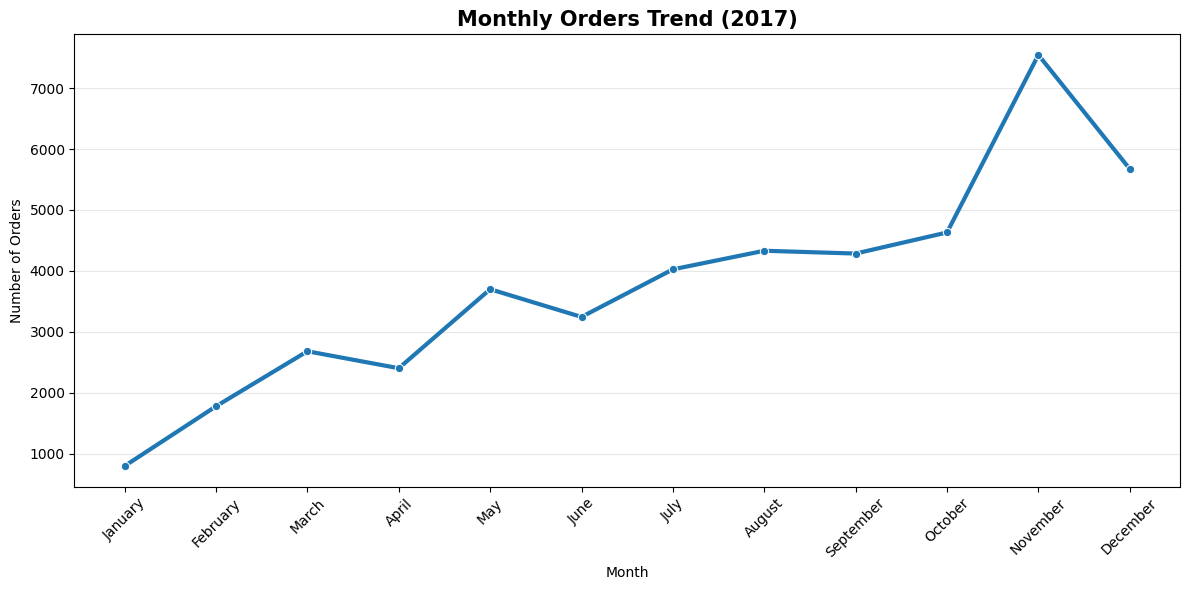

In [20]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x="Month",
    y="Orders",
    marker="o",
    linewidth=3
)

plt.title("Monthly Orders Trend (2017)", fontsize=15, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 💡 Business Insights

- Monthly order volume shows a consistent upward trend throughout 2017, reflecting strong business growth.
- November recorded the highest number of orders, indicating the impact of seasonal shopping events such as Black Friday.
- The fourth quarter (October–December) generated significantly higher demand compared to the first half of the year.
- Businesses should strengthen inventory planning, logistics, and marketing campaigns before peak shopping months to maximize sales.

### 📌 Business Recommendation

Based on the observed demand trend, the company should proactively increase inventory levels and optimize warehouse operations before the peak sales season. Marketing budgets should also be concentrated during high-demand months to maximize customer acquisition and revenue.

# 🛍 Product & Category Analysis

This section evaluates product performance, category-wise revenue, and purchasing patterns.

### Business Question

Which product categories generate the highest revenue, and how can these insights support inventory planning and marketing decisions?

In [25]:
query = """ select upper(products.product_category_name) as category,
round(sum(payments.payment_value),2) as sales
from products join order_items 
on products.product_id = order_items.product_id
join payments 
on payments.order_id = order_items.order_id
group by category
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Category", "Sales"])
df

,Category,Sales
0,PERFUMARIA,506738.66
1,MOVEIS_DECORACAO,1430176.39
2,TELEFONIA,486882.05
3,FASHION_BOLSAS_E_ACESSORIOS,218158.28
4,CAMA_MESA_BANHO,1712553.67
...,...,...
69,CDS_DVDS_MUSICAIS,1199.43
70,LA_CUISINE,2913.53
71,FASHION_ROUPA_INFANTO_JUVENIL,785.67
72,PC_GAMER,2174.43


In [26]:
print(df.columns)

Index(['Category', 'Sales'], dtype='object')


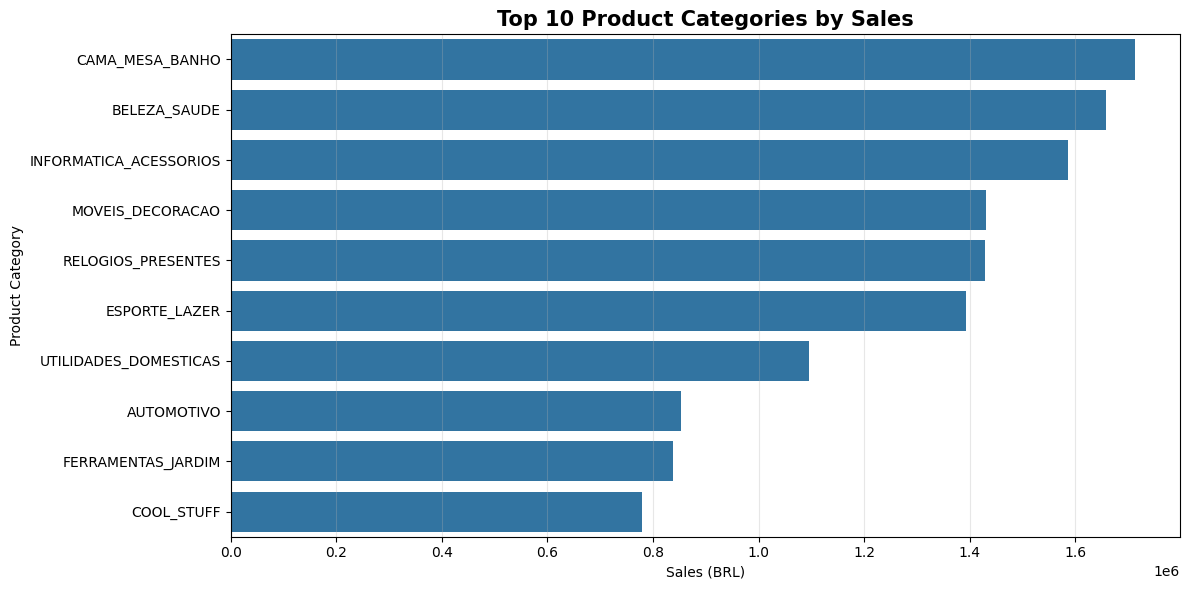

In [27]:
# Top 10 Categories by Sales

top10 = df.nlargest(10, "Sales")

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Sales",
    y="Category"
)

plt.title("Top 10 Product Categories by Sales", fontsize=15, fontweight="bold")
plt.xlabel("Sales (BRL)")
plt.ylabel("Product Category")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### 💡 Business Insights

- Home & Living (CAMA_MESA_BANHO) generated the highest sales among all product categories.
- Beauty & Health, Computer Accessories, and Home Decor also contributed significantly to overall revenue.
- A relatively small group of categories accounts for a large share of total sales, indicating a Pareto-like distribution.
- Prioritizing inventory and marketing for these high-performing categories can significantly improve overall business revenue.

### 📌 Business Recommendation

Increase inventory availability and promotional investments for the highest-performing categories while periodically reviewing low-performing categories for pricing optimization, product assortment, or discontinuation decisions.

# 💳 Payment Analysis

This section examines customer payment preferences and installment usage.

### Business Question

Which payment methods are most preferred by customers, and how should the business optimize payment offerings?

In [29]:
query = """
SELECT
    payment_type,
    COUNT(*) AS total_orders
FROM payments
GROUP BY payment_type
ORDER BY total_orders DESC;
"""

cur.execute(query)

data = cur.fetchall()

payment_df = pd.DataFrame(data, columns=["Payment Method", "Orders"])

payment_df

,Payment Method,Orders
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


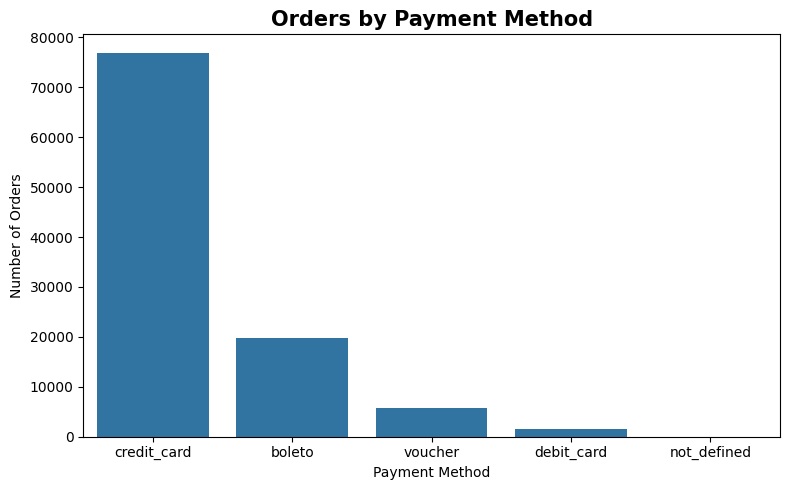

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=payment_df,
    x="Payment Method",
    y="Orders"
)

plt.title("Orders by Payment Method", fontsize=15, fontweight="bold")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

## 💡 Business Insights

- Credit Card is the most preferred payment method, accounting for the majority of customer transactions.
- Boleto is the second most frequently used payment option, indicating that many customers still prefer bank slip payments.
- Voucher and Debit Card contribute only a small share of total orders.
- Businesses should prioritize optimizing the credit card payment experience while continuing to support alternative payment methods for broader customer accessibility.

## 📌 Business Recommendation

- Offer cashback, EMI options, and loyalty rewards for credit card users to increase repeat purchases.
- Continue supporting Boleto payments for customers who prefer traditional payment methods.
- Improve awareness and promotional campaigns for debit card and digital payment options to diversify payment usage.

Count the number of customers from each state.

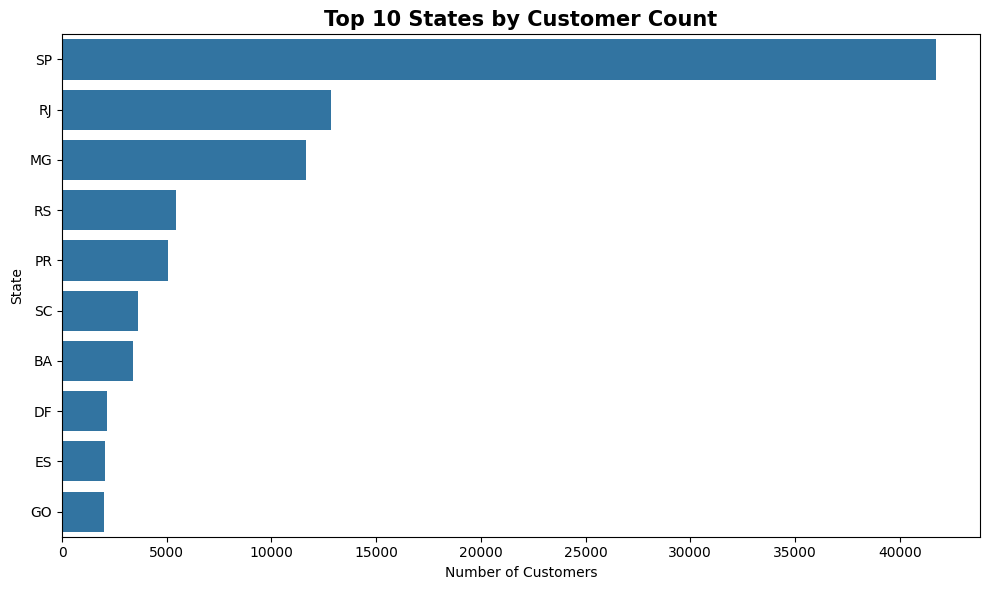

In [31]:
query = """ select customer_state ,count(customer_id)
from customers group by customer_state
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["state", "customer_count" ])
df = df.sort_values(by = "customer_count", ascending= False)

# Top 10 States by Customer Count

top10_states = df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_states,
    x="customer_count",
    y="state"
)

plt.title("Top 10 States by Customer Count", fontsize=15, fontweight="bold")
plt.xlabel("Number of Customers")
plt.ylabel("State")

plt.tight_layout()
plt.show()

## 💡 Business Insights

- São Paulo (SP) has the highest customer concentration, making it the company's largest market.
- Rio de Janeiro (RJ) and Minas Gerais (MG) are the next largest customer markets.
- Customer demand is concentrated in a few major states, indicating strong regional purchasing behavior.
- These states should be prioritized for inventory allocation, warehouse planning, and targeted marketing campaigns.

## 📌 Business Recommendation

- Maintain higher inventory levels in SP, RJ, and MG to reduce stock-out risks.
- Optimize warehouse and logistics operations near high-demand regions to improve delivery performance.
- Launch localized marketing campaigns in lower-demand states to expand the customer base.

Calculate the number of orders per month in 2018.

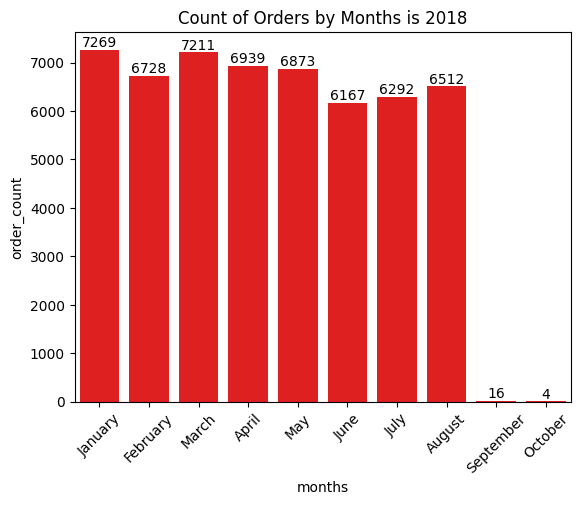

In [7]:
query = """ select monthname(order_purchase_timestamp) months, count(order_id) order_count
from orders where year(order_purchase_timestamp) = 2018
group by months
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["months", "order_count"])
o = ["January", "February","March","April","May","June","July","August","September","October"]

ax = sns.barplot(x = df["months"],y =  df["order_count"], data = df, order = o, color = "red")
plt.xticks(rotation = 45)
ax.bar_label(ax.containers[0])
plt.title("Count of Orders by Months is 2018")

plt.show()

Find the average number of products per order, grouped by customer city.

In [8]:
query = """with count_per_order as 
(select orders.order_id, orders.customer_id, count(order_items.order_id) as oc
from orders join order_items
on orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id)

select customers.customer_city, round(avg(count_per_order.oc),2) as average_orders
from customers join count_per_order
on customers.customer_id = count_per_order.customer_id
group by customers.customer_city order by average_orders desc
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns = ["customer city", "average products/order"])
df.head(10)

,customer city,average products/order
0,padre carvalho,7.00
1,celso ramos,6.50
2,datas,6.00
3,candido godoi,6.00
4,matias olimpio,5.00
5,cidelandia,4.00
6,picarra,4.00
7,morro de sao paulo,4.00
8,teixeira soares,4.00
9,curralinho,4.00


Calculate the percentage of total revenue contributed by each product category.

In [9]:
query = """select upper(products.product_category_name) category, 
round((sum(payments.payment_value)/(select sum(payment_value) from payments))*100,2) as sales_percentage
from products join order_items 
on products.product_id = order_items.product_id
join payments 
on payments.order_id = order_items.order_id
group by category order by sales_percentage desc"""


cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ["Category", "percentage distribution"])
df.head()

,Category,percentage distribution
0,CAMA_MESA_BANHO,10.70
1,BELEZA_SAUDE,10.35
2,INFORMATICA_ACESSORIOS,9.90
3,MOVEIS_DECORACAO,8.93
4,RELOGIOS_PRESENTES,8.93


Identify the correlation between product price and the number of times a product has been purchased.

In [10]:
import numpy as np
cur = db.cursor()
query = """select products.product_category_name, 
count(order_items.product_id),
round(avg(order_items.price),2)
from products join order_items
on products.product_id = order_items.product_id
group by products.product_category_name"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ["Category", "order_count","price"])

arr1 = df["order_count"]
arr2 = df["price"]

a = np.corrcoef([arr1,arr2])
print("the correlation is", a[0][-1])

the correlation is -0.10631514167157562


### Business Question

Which sellers generate the highest revenue, and how can these insights help optimize seller partnerships and marketplace performance?

In [32]:
query = """
SELECT
    order_items.seller_id,
    ROUND(SUM(payments.payment_value),2) AS revenue
FROM order_items
JOIN payments
ON order_items.order_id = payments.order_id
GROUP BY order_items.seller_id
ORDER BY revenue DESC
LIMIT 10;
"""

cur.execute(query)

data = cur.fetchall()

seller_df = pd.DataFrame(data, columns=["Seller ID", "Revenue"])

seller_df

,Seller ID,Revenue
0,7c67e1448b00f6e969d365cea6b010ab,507166.91
1,1025f0e2d44d7041d6cf58b6550e0bfa,308222.04
2,4a3ca9315b744ce9f8e9374361493884,301245.27
3,1f50f920176fa81dab994f9023523100,290253.42
4,53243585a1d6dc2643021fd1853d8905,284903.08
5,da8622b14eb17ae2831f4ac5b9dab84a,272219.32
6,4869f7a5dfa277a7dca6462dcf3b52b2,264166.12
7,955fee9216a65b617aa5c0531780ce60,236322.30
8,fa1c13f2614d7b5c4749cbc52fecda94,206513.23
9,7e93a43ef30c4f03f38b393420bc753a,185134.21


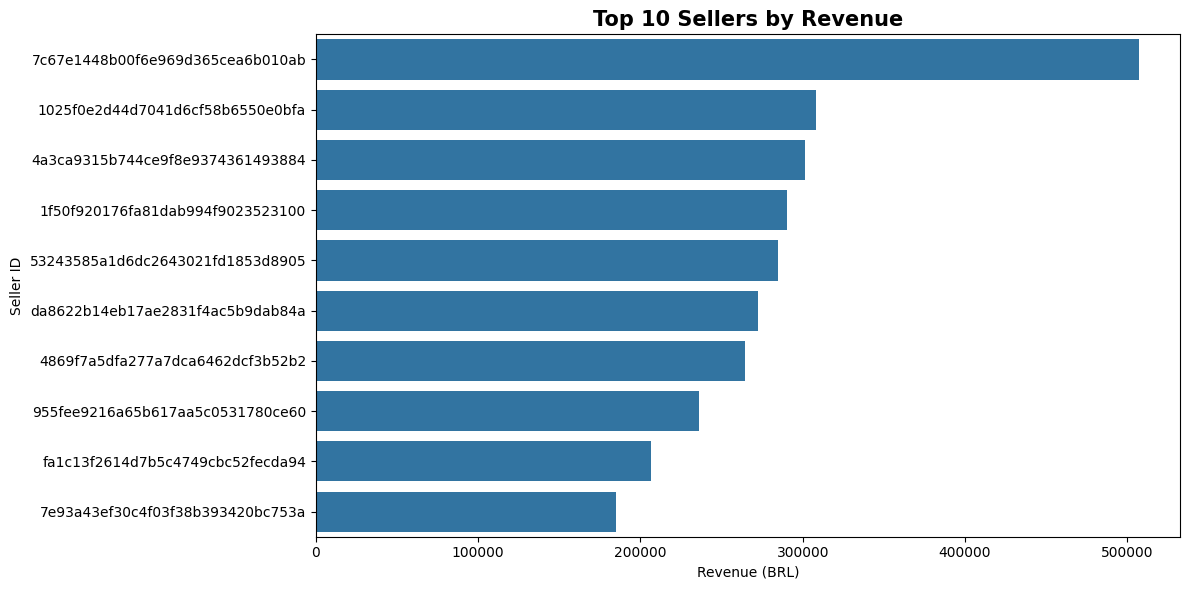

In [33]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=seller_df,
    x="Revenue",
    y="Seller ID"
)

plt.title("Top 10 Sellers by Revenue", fontsize=15, fontweight="bold")
plt.xlabel("Revenue (BRL)")
plt.ylabel("Seller ID")

plt.tight_layout()
plt.show()

## 💡 Business Insights

- A small group of sellers contributes a disproportionately high share of marketplace revenue.
- Revenue distribution among sellers is highly concentrated, indicating the presence of top-performing sellers.
- Strengthening relationships with high-performing sellers can significantly improve overall marketplace performance.
- Lower-performing sellers may benefit from targeted onboarding, pricing support, and promotional campaigns.

## 📌 Business Recommendation

- Develop loyalty and incentive programs for top-performing sellers.
- Monitor seller performance regularly using revenue-based KPIs.
- Provide training and promotional support to emerging sellers to improve overall marketplace competitiveness.

# ❤️ Customer Retention Analysis

This section analyzes repeat purchasing behavior, customer retention, and high-value customers.

### Business Question

How does customer spending evolve over time, and what purchasing patterns can be observed from repeat customers?

In [12]:
query = """select customer_id, order_purchase_timestamp, payment,
avg(payment) over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from
(select orders.customer_id, orders.order_purchase_timestamp, 
payments.payment_value as payment
from payments join orders
on payments.order_id = orders.order_id) as a"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=["customer_id", "order_purchase_timestamp", "payment", "moving_avg_payment"])
df

,customer_id,order_purchase_timestamp,payment,moving_avg_payment
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,71.23,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000


In [34]:
top_customers = (
    df.groupby("customer_id")["payment"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_customers,
    x="payment",
    y="customer_id"
)

plt.title("Top 10 Customers by Total Spending", fontsize=15, fontweight="bold")
plt.xlabel("Total Spending (BRL)")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

KeyError: 'customer_id'

Calculate the cumulative sales per month for each year.

In [13]:
query = """select years, months , payment, sum(payment)
over(order by years, months) cumulative_sales from 
(select year(orders.order_purchase_timestamp) as years,
month(orders.order_purchase_timestamp) as months,
round(sum(payments.payment_value),2) as payment from orders join payments
on orders.order_id = payments.order_id
group by years, months order by years, months) as a
"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=["year", "month", "monthly_sales", "cumulative_sales"])
df

,year,month,monthly_sales,cumulative_sales
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,197850.38
4,2017,2,291908.01,489758.39
5,2017,3,449863.60,939621.99
6,2017,4,417788.03,1357410.02
7,2017,5,592918.82,1950328.84
8,2017,6,511276.38,2461605.22
9,2017,7,592382.92,3053988.14


Calculate the year-over-year growth rate of total sales.

In [14]:
query = """with a as(select year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value),2) as payment from orders join payments
on orders.order_id = payments.order_id
group by years order by years)

select years, ((payment - lag(payment, 1) over(order by years))/
lag(payment, 1) over(order by years)) * 100 from a"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years", "yoy % growth"])
df

,years,yoy % growth
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [15]:
query = """
with a as (
    select customers.customer_id,
           min(orders.order_purchase_timestamp) as first_order
    from customers 
    join orders
        on customers.customer_id = orders.customer_id
    group by customers.customer_id
),

b as (
    select a.customer_id
    from a 
    join orders
        on orders.customer_id = a.customer_id
       and orders.order_purchase_timestamp > first_order
       and orders.order_purchase_timestamp < date_add(first_order, interval 6 month)
    group by a.customer_id
)

select 
    100.0 * count(distinct b.customer_id) / count(distinct a.customer_id) 
        as repeat_rate_6m
from a 
left join b 
    on a.customer_id = b.customer_id;
"""
cur.execute(query)
data = cur.fetchall()

data[0][0]

Decimal('0.00000')

Identify the top 3 customers who spent the most money in each year.

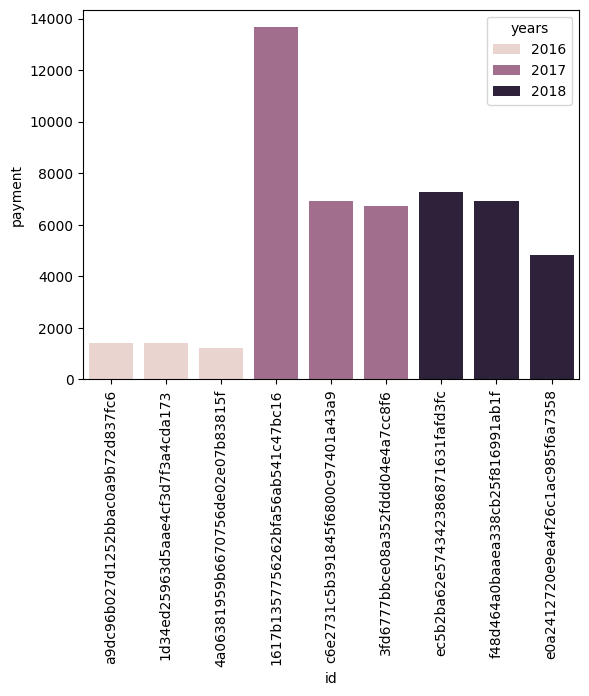

In [16]:
query = """select years, customer_id, payment, d_rank
from
(select year(orders.order_purchase_timestamp) years,
orders.customer_id,
sum(payments.payment_value) payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp)
order by sum(payments.payment_value) desc) d_rank
from orders join payments 
on payments.order_id = orders.order_id
group by year(orders.order_purchase_timestamp),
orders.customer_id) as a
where d_rank <= 3 ;"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years","id","payment","rank"])
sns.barplot(x = "id", y = "payment", data = df, hue = "years")
plt.xticks(rotation = 90)
plt.show()